In [1]:
import sys
print(sys.version)
print(sys.executable)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
c:\Users\ecbas\Documents\Tea_Leaf_Quality_Detector\venv\Scripts\python.exe


In [2]:
import tensorflow as tf

In [3]:
import os
import glob
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image, ImageStat, ImageOps
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import confusion_matrix, classification_report, fbeta_score, accuracy_score

import warnings
warnings.filterwarnings('ignore')


Dataset overview

In [4]:
# Check Dataset Distribution

import os

dataset_path = "tea_dataset"
total_count = 0

for folder in os.listdir(dataset_path):
    count = len(os.listdir(os.path.join(dataset_path, folder)))
    print(folder, count)

    total_count += count  # 2. Add the current folder's count to the total
print("-" * 20)
print(f"Total files across all folders: {total_count}")

Average_quality 508
Diseased 592
good_quallity 615
high_quality 562
Not_good_for_tea 523
--------------------
Total files across all folders: 2800


### EDA and Visualize Images

Image quality

In [5]:
# check for bad images

total_images = 0
corrupted_images = 0

for folder in os.listdir("tea_dataset"):
    folder_path = os.path.join("tea_dataset", folder)

    if os.path.isdir(folder_path):
        for file in os.listdir(folder_path):
            total_images += 1
            try:
                img = Image.open(
                    os.path.join(folder_path, file)
                )
                img.verify()
            except Exception:
                corrupted_images += 1
                print("Corrupted:", file)

print(f"Total images: {total_images}")
print(f"Corrupted images: {corrupted_images}")

Total images: 2800
Corrupted images: 0


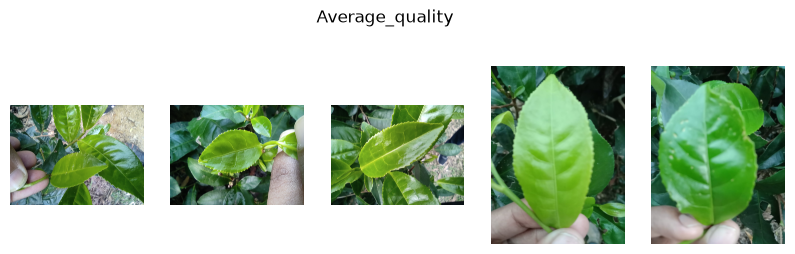

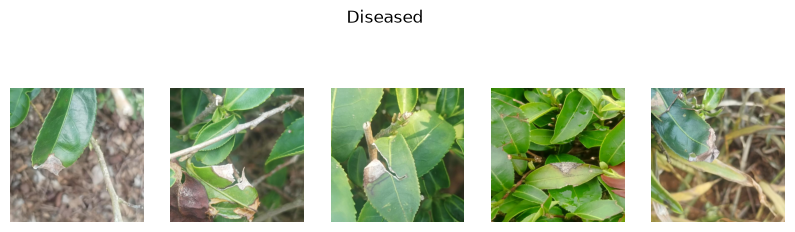

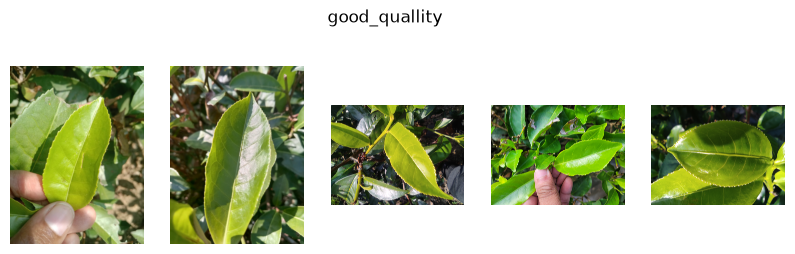

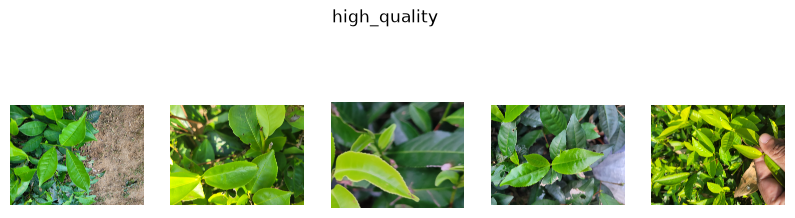

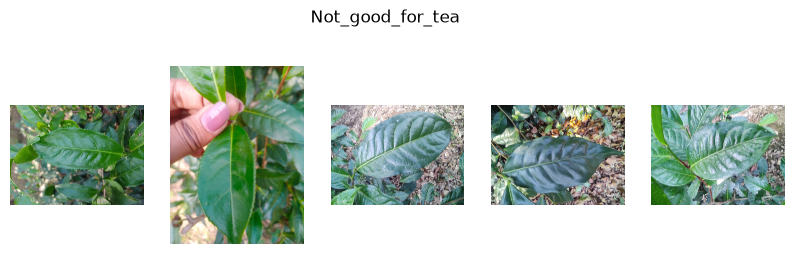

In [37]:


import random
dataset_path = "tea_dataset"

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        plt.figure(figsize=(10,3))

        files = random.sample(
            os.listdir(folder_path),
            min(5, len(os.listdir(folder_path)))
        )
        for i, file in enumerate(files):
            img = Image.open(
                os.path.join(folder_path, file)
            )
            plt.subplot(1,5,i+1)
            plt.imshow(img)
            plt.axis('off')
        plt.suptitle(folder)
        plt.show()
plt.show()

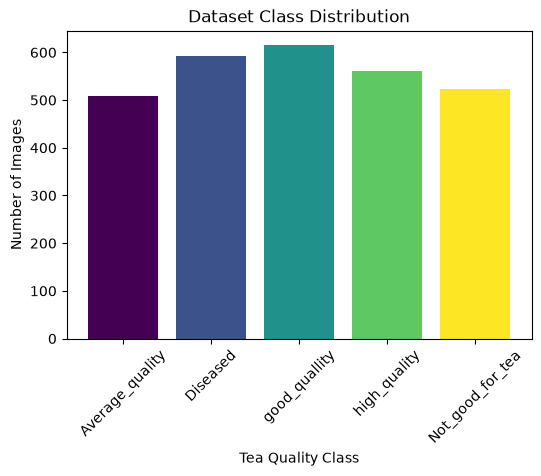

In [ ]:
# Class distribution

classes = []
counts = []

for folder in os.listdir(dataset_path):

    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        classes.append(folder)
        counts.append(len(os.listdir(folder_path)))

colors = plt.cm.viridis(np.linspace(0, 1, len(classes)))

plt.figure(figsize=(6,4))
plt.bar(classes, counts, color=colors)
plt.xticks(rotation=45)
plt.title("Dataset Class Distribution")
plt.xlabel("Tea Quality Class")
plt.ylabel("Number of Images")

plt.show()

Preprocessing

In [5]:
# Image settings
IMG_SIZE = (224,224)
BATCH_SIZE = 32

Data Augmentation

In [ ]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,       #Splits dataset into training and validation
    rotation_range=25,
    zoom_range=0.2,
    width_shift_range=0.1,
    #shear_range = 0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

# After training, use:
#Grad-CAM - Saliency Maps
#Saliency Maps
#t0 check what the model is looking at.
#If Grad-CAM highlights the hand:

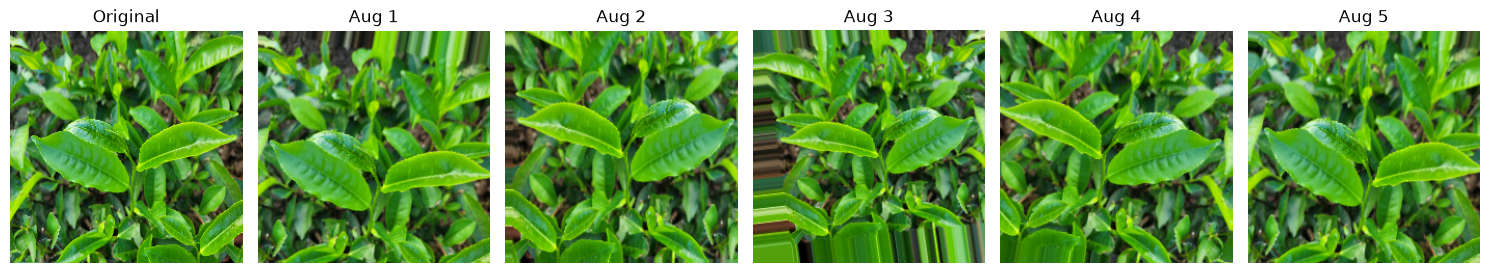

In [8]:
from tensorflow.keras.utils import load_img, img_to_array


# Load image
img_path = "tea_dataset/high_quality/20231224_160831.jpg"

img = load_img(img_path, target_size=(224,224))
img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

#Augmentation settings
# datagen = ImageDataGenerator(
#     rotation_range=20,
#     zoom_range=0.2,
#     width_shift_range=0.2,
#     height_shift_range=0.2,
#     horizontal_flip=True
# )
datagen = ImageDataGenerator(
    #rescale=1./255,
    validation_split=0.2,       #Splits dataset into training and validation
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.1,
    shear_range = 0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)


# Create augmented images
aug_iter = datagen.flow(img_array, batch_size=1)

plt.figure(figsize=(15,5))

# Original image
plt.subplot(1,6,1)
plt.imshow(img)
plt.title("Original")
plt.axis("off")

# 5 augmented versions
for i in range(5):

    batch = next(aug_iter)

    aug_img = batch[0].astype("uint8")

    plt.subplot(1,6,i+2)
    plt.imshow(aug_img)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Load and Train

In [9]:
#Train data
train_data = datagen.flow_from_directory(
    dataset_path,

    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

#Validation data
val_data = datagen.flow_from_directory(
    dataset_path,

    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False           # turn off shuffle
)

Found 2242 images belonging to 5 classes.
Found 558 images belonging to 5 classes.


In [10]:
print(train_data.class_indices)

{'Average_quality': 0, 'Diseased': 1, 'Not_good_for_tea': 2, 'good_quallity': 3, 'high_quality': 4}


In [11]:
#save it
class_names = list(train_data.class_indices.keys())
print(class_names)

['Average_quality', 'Diseased', 'Not_good_for_tea', 'good_quallity', 'high_quality']


Create callbacks

In [12]:
# Early stoppage
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',         # what to watch
    patience=5,
    restore_best_weights=True   # go back to best model
)

In [13]:
# Save best model automatically
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint = ModelCheckpoint(
    "best_model.keras",

    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

CNN TRAINING

In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2

cnn_model = Sequential([

    Conv2D(32,(3,3),activation='relu', input_shape=(224,224,3), kernel_regularizer=l2(0.001)),
    MaxPooling2D(),
    Dropout(0.2),

    Conv2D(64,(3,3),activation='relu', kernel_regularizer=l2(0.001)), MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu', kernel_regularizer=l2(0.001)), MaxPooling2D(),

    Flatten(),

    Dense(256,activation='relu'), Dropout(0.5),

    Dense(5,activation='softmax')
])
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,957 (84.86 MB)

 Trainable params: 22,245,957 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# compile

from tensorflow.keras.optimizers import Adam

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),               # how to learn - learning rate.
    #optimizer='adam',  
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train

cnn_history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)



TypeError: 'tuple' object cannot be interpreted as an integer